# Lakeside EnergyPlus multi-resolution validation & calibration audit

Executed tutorial / audit record. **Authoritative site data** via `LAKESIDE_SITE_ROOT`.

**Physics honesty:** staged IDF uses `ZoneHVAC:IdealLoadsAirSystem` + fixed-COP electrical proxy. Filename `gshp` is naming only — not a GSHP plant model.

**Evidence products (never blended):**
- A. Utility-bill monthly calibration
- B. Interval-meter → monthly reconciliation
- C. Hourly interval validation
- D. Fifteen-minute DSM diagnostic

Monthly aggregation can hide hourly failure: mean energy can look fine while peaks, baseload, and morning ramp are wrong.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SITE = Path(os.environ.get("LAKESIDE_SITE_ROOT", r"C:\Users\ben\OneDrive\Desktop\testing\sp_creekside"))
APP = Path("..").resolve() if (Path("..") / "ml").is_dir() else Path(".").resolve()
for p in (APP, APP / "ml", APP / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

os.environ["LAKESIDE_SITE_ROOT"] = str(SITE)

def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest().upper()

try:
    git_sha = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=APP.parent, text=True).strip()
except Exception as e:
    git_sha = f"unknown:{e}"

baseline_path = SITE / "reports" / "eplus" / "baseline" / "immutable_baseline_v1.json"
val_path = SITE / "reports" / "eplus" / "multires" / "eplus_multires_validation.json"
print("SITE", SITE)
print("git", git_sha)
print("baseline", baseline_path.is_file(), baseline_path)
print("validation", val_path.is_file(), val_path)

SITE C:\Users\ben\OneDrive\Desktop\testing\sp_creekside
git 15d8cf7a6c0eebf7ceaf7bc26f5b8bcf63ab4c56
baseline True C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\reports\eplus\baseline\immutable_baseline_v1.json
validation True C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\reports\eplus\multires\eplus_multires_validation.json


In [2]:
# Load frozen baseline + live validation (utility vs interval kept separate)
baseline = json.loads(baseline_path.read_text(encoding="utf-8")) if baseline_path.is_file() else {}
val = json.loads(val_path.read_text(encoding="utf-8")) if val_path.is_file() else {}
res = val.get("resolutions") or {}

rows = []
for key, title in [
    ("monthly_utility", "A utility bills"),
    ("monthly_interval", "B interval→monthly"),
    ("hourly", "C hourly"),
    ("q15_dsm", "D 15-min DSM"),
]:
    b = res.get(key) or {}
    rows.append({
        "product": title,
        "source_type": b.get("source_type"),
        "status": b.get("status"),
        "n": b.get("n"),
        "p": b.get("p"),
        "nmbe_pct": b.get("nmbe_pct"),
        "cvrmse_pct": b.get("cvrmse_pct"),
        "rmse_kw": b.get("rmse_kw"),
        "mae_kw": b.get("mae_kw"),
        "label": b.get("label"),
        "labeled_as_gl14": b.get("labeled_as_gl14"),
    })
metrics_df = pd.DataFrame(rows)
metrics_df

,product,source_type,status,n,p,nmbe_pct,cvrmse_pct,rmse_kw,mae_kw,label,labeled_as_gl14
0,A utility bills,utility_bill_monthly,pass,10,1,-0.079000,11.444000,NaN,NaN,PARTIAL-PERIOD MONTHLY THRESHOLD SCREEN (utili...,False
1,B interval→monthly,interval_meter_monthly,pass,11,1,3.010669,11.488562,NaN,NaN,PARTIAL-PERIOD MONTHLY THRESHOLD SCREEN (inter...,False
2,C hourly,None,fail,8064,1,2.789433,96.971325,63.924358,44.216085,None,False
3,D 15-min DSM,None,diagnostic_only,32253,1,2.787632,114.686011,75.610024,46.790071,None,False


## Why monthly can look fine while hourly fails

NMBE/CVRMSE on monthly energy averages cancel positive and negative hourly residuals. A model can match monthly kWh while misplacing peaks, overnight baseload, and morning warm-up — fatal for 15-minute DSM.

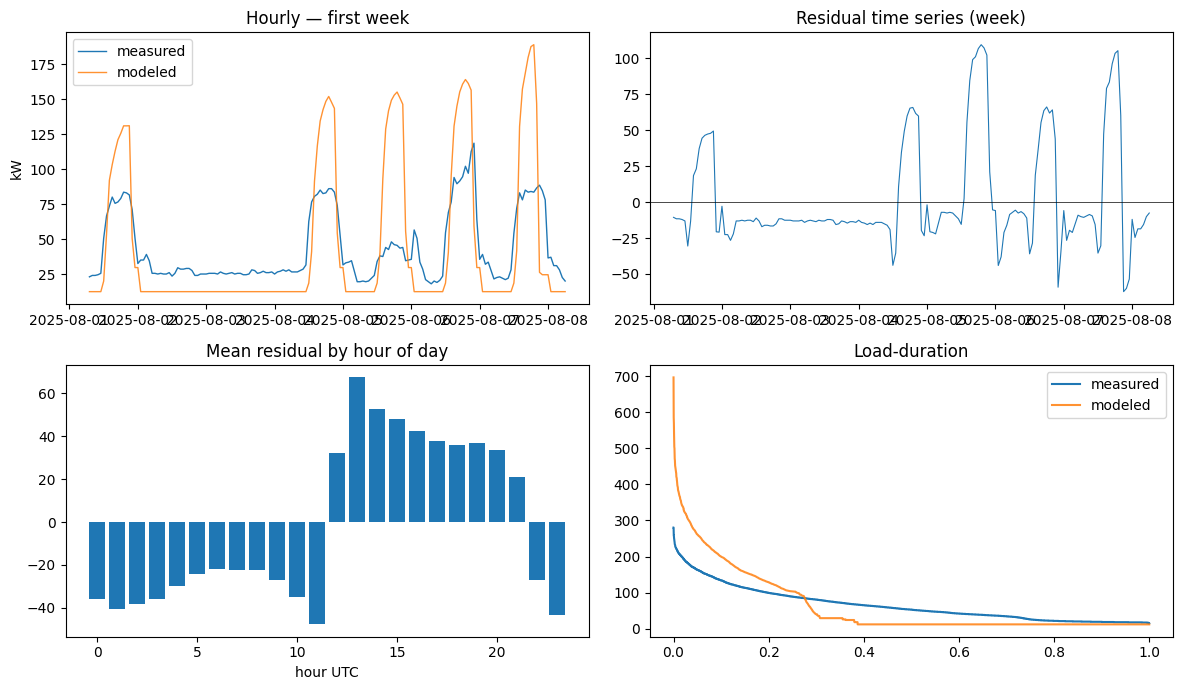

saved C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\reports\eplus\multires\plots\notebook_hourly_gallery.png


In [3]:
aligned_path = SITE / "reports" / "eplus" / "multires" / "aligned_hourly_kw.csv"
aligned = pd.read_csv(aligned_path) if aligned_path.is_file() else pd.DataFrame()
if len(aligned):
    aligned["ts"] = pd.to_datetime(aligned["interval_end_utc"], utc=True)
    obs_col = "observed_kw" if "observed_kw" in aligned.columns else "kw_meas"
    sim_col = "simulated_kw" if "simulated_kw" in aligned.columns else "kw_mod"
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    sample = aligned.iloc[: 24 * 7]
    axes[0, 0].plot(sample["ts"], sample[obs_col], label="measured", lw=1)
    axes[0, 0].plot(sample["ts"], sample[sim_col], label="modeled", lw=1, alpha=0.85)
    axes[0, 0].set_title("Hourly — first week"); axes[0, 0].legend(); axes[0, 0].set_ylabel("kW")
    resid = sample[sim_col] - sample[obs_col]
    axes[0, 1].plot(sample["ts"], resid, lw=0.8)
    axes[0, 1].axhline(0, color="k", lw=0.5)
    axes[0, 1].set_title("Residual time series (week)")
    hod = aligned["ts"].dt.hour
    by_h = (aligned[sim_col] - aligned[obs_col]).groupby(hod).mean()
    axes[1, 0].bar(by_h.index, by_h.values)
    axes[1, 0].set_title("Mean residual by hour of day"); axes[1, 0].set_xlabel("hour UTC")
    o = np.sort(aligned[obs_col].to_numpy())[::-1]
    s = np.sort(aligned[sim_col].to_numpy())[::-1]
    x = np.arange(len(o)) / max(len(o), 1)
    axes[1, 1].plot(x, o, label="measured"); axes[1, 1].plot(x, s, label="modeled", alpha=0.85)
    axes[1, 1].set_title("Load-duration"); axes[1, 1].legend()
    fig.tight_layout()
    out_fig = SITE / "reports" / "eplus" / "multires" / "plots" / "notebook_hourly_gallery.png"
    out_fig.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_fig, dpi=120)
    plt.show()
    print("saved", out_fig)
else:
    print("missing aligned_hourly_kw.csv — run validate_eplus_multires.py")

In [4]:
# Chronological periods (locked holdout must not tune)
periods = val.get("chronological_periods") or baseline.get("chronological_periods") or {}
pd.DataFrame([
    {"period": k, **({kk: vv for kk, vv in v.items()} if isinstance(v, dict) else {"value": v})}
    for k, v in periods.items()
    if k != "notes"
])

,period,start,end,n,role
0,calibration_development,2025-08-01 07:00:00+00:00,2026-01-31 00:00:00+00:00,4385,tuning_allowed
1,chronological_validation,2026-01-31 00:00:00+00:00,2026-03-31 00:00:00+00:00,1416,selection_allowed_not_final
2,winter_peak_validation,2026-01-01T00:00:00+00:00,2026-02-28 00:00:00+00:00,1392,peak_diagnostics
3,locked_final_holdout,2026-06-03 06:00:00+00:00,2026-07-03 06:00:00+00:00,721,locked_no_tuning


In [5]:
# Campaign leaderboard: only succeeded EnergyPlus trials count
camps_dir = SITE / "eplus" / "campaigns"
candidates = sorted(camps_dir.glob("*")) if camps_dir.is_dir() else []
summaries = []
for c in candidates:
    sp = c / "summary.json"
    if sp.is_file():
        summaries.append((c.name, json.loads(sp.read_text(encoding="utf-8"))))
if not summaries:
    mirror = APP / "ml" / "artifacts" / "eplus_campaigns" / "latest_summary.json"
    if mirror.is_file():
        summaries.append(("mirror", json.loads(mirror.read_text(encoding="utf-8"))))

camp_name, camp = summaries[-1] if summaries else ("none", {})
print("campaign", camp_name)
print("run_eplus", camp.get("run_eplus"), "n_succeeded", camp.get("n_succeeded"), "n_planned", camp.get("n_planned_executable"))
board = pd.DataFrame(camp.get("leaderboard") or [])
board

campaign smoke_exec_20260807
run_eplus True n_succeeded 2 n_planned 2


,trial_id,knobs,hourly_cvrmse_pct,hourly_rmse_kw,hourly_status,rank_key,promote_allowed
0,B_equip_mult_lo,{'equip_mult': 0.7},93.648622,61.734002,fail,"[0, 64.127]",False
1,B_equip_mult_mid,{'equip_mult': 1.0},96.971325,63.924358,fail,"[0, 66.971]",False


In [6]:
structural = camp.get("structural") or {}
before = camp.get("before_hourly") or {}
best = camp.get("best_after") or {}
print("BEFORE hourly CVRMSE%", before.get("cvrmse_pct"), "RMSE_kW", before.get("rmse_kw"))
print("BEST AFTER", best)
print("STRUCTURAL", json.dumps(structural, indent=2))

overall = val.get("overall") or {}
hourly_pass = bool(overall.get("hourly_pass"))
util_pass = bool(overall.get("monthly_utility_pass") or overall.get("monthly_pass"))
ready = "READY" if (hourly_pass and util_pass and overall.get("recommendation_allowed")) else "NO-GO"
conclusion = {
    "operational_dsm_readiness": ready,
    "auto_generated": True,
    "hourly_pass": hourly_pass,
    "monthly_utility_partial_screen_pass": util_pass,
    "unqualified_gl14_full_year": False,
    "reason": overall.get("blocker_reason") or structural.get("verdict") or "gates_not_met",
    "physics": val.get("physics_label") or structural.get("physics"),
    "recommendation": structural.get("recommendation")
    or "Fail-closed: use measured-data ML for absolute kW; E+ monthly/engineering only until plant model exists",
}
print("\n=== AUTO CONCLUSION ===")
print(json.dumps(conclusion, indent=2))
out_concl = SITE / "reports" / "eplus" / "multires" / "notebook_auto_conclusion.json"
out_concl.write_text(json.dumps(conclusion, indent=2) + "\n", encoding="utf-8")
assert conclusion["operational_dsm_readiness"] in {"READY", "NO-GO"}
assert conclusion["unqualified_gl14_full_year"] is False

BEFORE hourly CVRMSE% 96.97132546478839 RMSE_kW 63.92435818498172
BEST AFTER {'trial_id': 'B_equip_mult_lo', 'knobs': {'equip_mult': 0.7}, 'hourly_cvrmse_pct': 93.648621584703, 'hourly_rmse_kw': 61.73400230446595, 'hourly_status': 'fail', 'rank_key': [0, 64.127], 'promote_allowed': False}
STRUCTURAL {
  "physics": "IdealLoads + fixed-COP proxy (filename gshp is naming only)",
  "n_executed_succeeded": 2,
  "all_succeeded_fail_hourly": true,
  "verdict": "BOUNDED_SEARCH_FAILED_HOURLY \u2014 IdealLoads+fixed-COP did not meet hourly screen under executed knobs; do not claim GSHP plant fidelity",
  "recommendation": "A) Build physically meaningful plant/heat-pump model, or B) Restrict E+ to monthly/engineering benchmark; use measured-data ML for absolute facility kW and zone temperatures"
}

=== AUTO CONCLUSION ===
{
  "operational_dsm_readiness": "NO-GO",
  "auto_generated": true,
  "hourly_pass": false,
  "monthly_utility_partial_screen_pass": true,
  "unqualified_gl14_full_year": false,